# Statistika hráčů a zápasů NHL
## Jan Beneš - 2026

### Původ dat
Používal jsem data https://www.kaggle.com/datasets/martinellis/nhl-game-data ze kterých jsem si vybral jen potřebné části.

### Struktura dat
`zapasove_statistiky.csv`
- Sloupce: Home, Away, Goals_home, Goals_away, First_goal_team, Winner
- vzorek o velikosti cca 2000 záznamů

`hracske_statistiky.csv`
- Sloupce: Player, Age, Avg_ice_time
- vzorek o velikosti cca 800 záznamů

### Načtení dat

In [2]:
import pandas as pd

df_games = pd.read_csv('./data/zapasove_statistiky.csv')
df_players = pd.read_csv('./data/hracske_statistiky.csv')

print("Zápasové statistiky")
print("===================")
print(df_games.head())

print()

print("Hráčské statistiky")
print("==================")
print(df_players.head())

Zápasové statistiky
       Home        Away  Goals_home Goals_away First_goal_team      Winner
0   Toronto      Ottawa           5          3         Toronto     Toronto
1  St Louis  Washington           2          3        St Louis  Washington
2  Edmonton   Vancouver           3          2       Vancouver    Edmonton
3     Vegas    San Jose           4          1           Vegas       Vegas
4   Toronto      Ottawa           5          3         Toronto     Toronto

Hráčské statistiky
            Player  Age  Avg_ice_time
0      Zdeno Chara   42         20.89
1     Joe Thornton   40         15.50
2  Patrick Marleau   40         15.58
3      Ron Hainsey   38         20.68
4  Justin Williams   38         13.62


### 1. hypotéza - Permutační test
$h_0$ = Domácí prostředí nemá vliv na počet vstřelených branek.\
$h_1$ = Počet vstřelených branek je v domácím prostředí vyšší. => jednostranně

Testová statistika - $T = Avg(X_{goals\_home}) - Avg(X_{goals\_away})$

P-hodnota = 0.0055


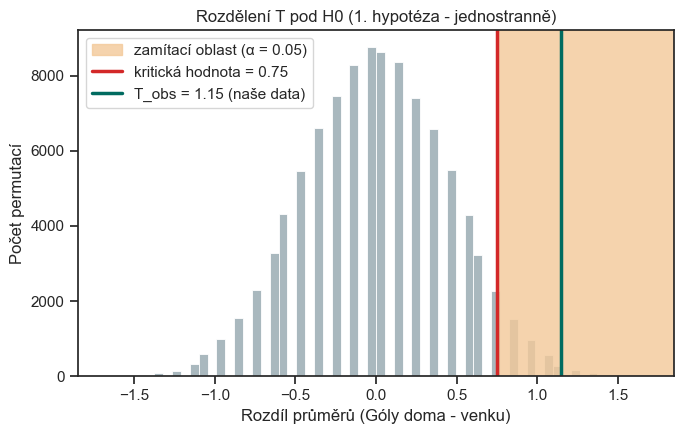

In [ ]:
from scipy.stats import permutation_test
import numpy as np
from visualize import visualize_permutation_test, visualize_regression

# Načtení dat
goals_home = df_games['Goals_home'].head(20).astype(float).to_numpy() # TODO: odstranit head
goals_away = df_games['Goals_away'].head(20).astype(float).to_numpy() # TODO: odstranit head

# Testová statistika
def avg_difference(x, y):
    return np.mean(x) - np.mean(y)

# Simulace
result = permutation_test(
    data = (goals_home, goals_away),
    statistic = avg_difference,
    # Zvolil jsem 'samples', protože potřebuji prohazovat horizontálně, tedy góly domácích s góly hostů. Respektive předstírat, že tým hrál venku a ne doma a dal daný počet gólů
    permutation_type='samples',
    n_resamples=100_000,
    alternative='greater'
)

# Vizualizace
print(f"P-hodnota = {result.pvalue:.4f}")

visualize_permutation_test(
    result,
    alternative='greater',
    title='Rozdělení T pod H0 (1. hypotéza - jednostranně)',
    xlabel='Rozdíl průměrů (Góly doma - venku)'
)

### 2. hypotéza - Permutační test
$h_0$ = Výsledek zápasu nezáleží na tom, který z týmů vstřelí první branku.\
$h_1$ = Výsledek zápasu záleží na tom, kdo vstřelí první branku.

Testová statistika - $T = Avg(X_{first\_goal\_team} = X_{winner})$


--- Výsledek 2. hypotézy ---
Skutečná úspěšnost týmu s prvním gólem: 61.00 %
P-hodnota: 0.0548


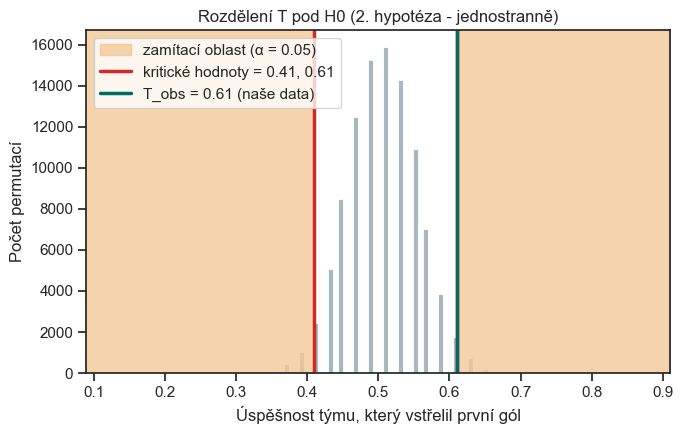

In [ ]:
# Načtení dat
home = df_games['Home'].head(100).astype(str).to_numpy()

first_goal_team_str = df_games['First_goal_team'].head(100).astype(str).to_numpy() # TODO: odstranit head
winner_str = df_games['Winner'].head(100).astype(str).to_numpy() # TODO: odstranit head

first_goal_team = (home == first_goal_team_str).astype(int)
winner = (home == winner_str).astype(int)

# Testová statistika
def first_goal_team_is_winner_percantage(x, y):
    return np.mean(x == y)

result = permutation_test(
    data = (first_goal_team, winner),
    statistic = first_goal_team_is_winner_percantage,
    # Zvolil jsem typ 'pairings', protože chci prohazovat vertikálně jeden sloupec. Mělo by to fungovat, jelikož jsem si data převedl na 1 a 0, kde 1 reprezentuje domácí tým a 0 hostující.
    permutation_type='pairings',
    n_resamples=100_000,
    alternative='two-sided'
)

# Vizualizace
print(f"Skutečná úspěšnost týmu s prvním gólem: {result.statistic * 100:.2f} %")
print(f"P-hodnota: {result.pvalue:.4f}")

visualize_permutation_test(
    result, 
    alternative='two-sided', 
    title='Rozdělení T pod H0 (2. hypotéza - jednostranně)', 
    xlabel='Úspěšnost týmu, který vstřelil první gól'
)

### 3. hypotéza - Permutační test
$h_0$ = Mezi věkem a průměrným časem stráveným na ledě není vztah, korelace se rovná 0.\
$h_1$ = Výsledek zápasu záleží na tom, kdo vstřelí první branku. Korelace se nerovná 0.

Testová statistika - $T =$ korelace

P-hodnota: 0.8471


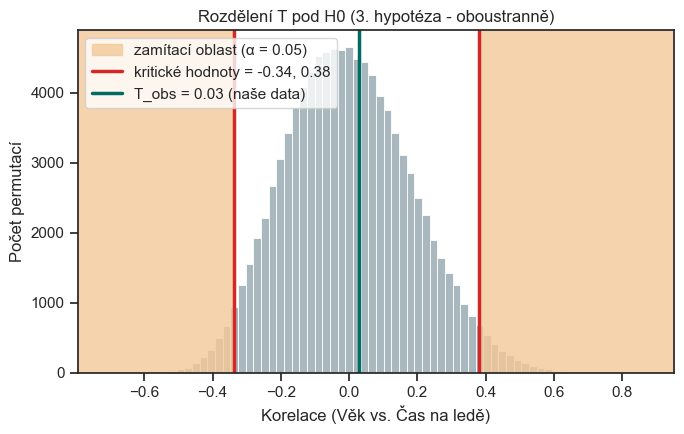

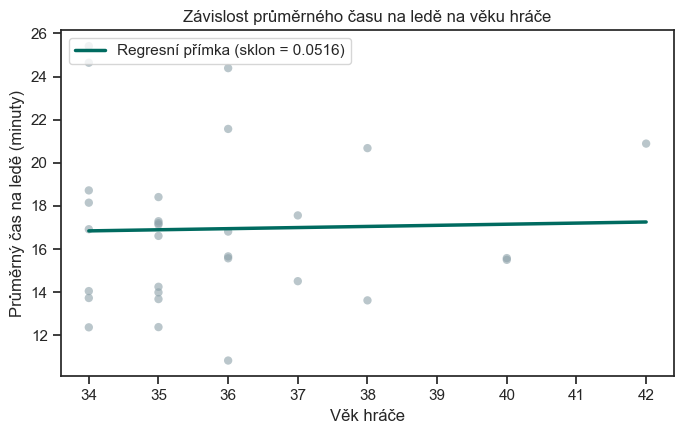

In [ ]:
# Načtení dat
player_age = df_players['Age'].head(30).astype(float).to_numpy() # TODO: odstranit head
avg_ice_time = df_players['Avg_ice_time'].head(30).astype(float).to_numpy() # TODO: odstranit head

# Testová statistika
def correlation(x, y):
    return np.corrcoef(x, y)[0, 1]

# Simulace
result = permutation_test(
    data = (player_age, avg_ice_time),
    statistic = correlation,
    # Zde jsem zvolil opět 'pairings', protože chci sledovat vztah mezi věkem a avg časem na ledě a tedy náhodně prohazovat čas na ledě mezi jednotlivými hráči.
    permutation_type='pairings',
    n_resamples=100_000,
    alternative='two-sided'
)

# Vizualizace
print(f"P-hodnota: {result.pvalue:.4f}")

visualize_permutation_test(
    result, 
    alternative='two-sided', 
    title='Rozdělení T pod H0 (3. hypotéza - oboustranně)', 
    xlabel='Korelace (Věk vs. Čas na ledě)'
)

visualize_regression(
    x=player_age, 
    y=avg_ice_time, 
    title='Závislost průměrného času na ledě na věku hráče',
    xlabel='Věk hráče',
    ylabel='Průměrný čas na ledě (minuty)'
)